In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/DeepfakeProject"

In [3]:
import sys
sys.path.append('/content/drive/MyDrive/DeepfakeProject')

In [4]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/DeepfakeProject/FaceForensics/csv/FF++_Metadata.csv")

df["File Path"].unique()

array(['DeepFakeDetection/01_02__meeting_serious__YVGY8LOK.mp4',
       'DeepFakeDetection/01_02__outside_talking_still_laughing__YVGY8LOK.mp4',
       'DeepFakeDetection/01_02__talking_against_wall__YVGY8LOK.mp4', ...,
       'original/997.mp4', 'original/998.mp4', 'original/999.mp4'],
      dtype=object)

In [5]:
allowed_folders = [
    "original",
    "Deepfakes",
    "FaceSwap",
    "DeepFakeDetection"
]

filtered_df = df[
    df["File Path"].str.split("/").str[0].isin(allowed_folders)
]

print(filtered_df.shape)
print(filtered_df["Label"].value_counts())

(4000, 8)
Label
FAKE    3000
REAL    1000
Name: count, dtype: int64


In [5]:
filtered_df.to_csv(
    "/content/drive/MyDrive/DeepfakeProject/FaceForensics/csv/FF++_Metadata_Filtered.csv",
    index=False
)

In [6]:
metadata=filtered_df
print(metadata.shape)
print(metadata["Label"].value_counts())

(4000, 8)
Label
FAKE    3000
REAL    1000
Name: count, dtype: int64


In [22]:
real_df = metadata[metadata["Label"] == "REAL"].sample(500)

fake_df = metadata[metadata["Label"] == "FAKE"].sample(
    n=len(real_df),
    random_state=42
)

balanced_df = pd.concat([real_df, fake_df])

print(balanced_df["Label"].value_counts())

Label
REAL    500
FAKE    500
Name: count, dtype: int64


In [7]:
pip install facenet_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 973.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2

In [1]:
import cv2, os, torch, numpy as np
from PIL import Image
from facenet_pytorch import MTCNN
from tqdm import tqdm
import pandas as pd

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [23]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.3,
    stratify=balanced_df["Label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Label"],
    random_state=42
)

In [24]:
dfs = []

for df, name in [
    (train_df, 'train'),
    (val_df, 'val'),
    (test_df, 'test')
]:
    tmp = df.copy()
    tmp['split'] = name
    dfs.append(tmp)

final_df = pd.concat(dfs, ignore_index=True)

print(final_df.shape)
print(final_df['split'].value_counts())

(1000, 9)
split
train    700
val      150
test     150
Name: count, dtype: int64


In [1]:
final_df.to_csv(f'/content/drive/MyDrive/DeepfakeProject/FaceForensics/csv/final_df.csv', index=False)
print('Saved final_df.csv')

NameError: name 'final_df' is not defined

In [41]:
final_df.head()

,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB),split
0,6340,original/340.mp4,REAL,293,1920,1080,h264,2.41,train
1,1817,Deepfakes/817_827.mp4,FAKE,419,1280,720,h264,1.89,train
2,6859,original/859.mp4,REAL,333,640,480,h264,0.45,train
3,787,DeepFakeDetection/21_04__talking_angry_couch__...,FAKE,1267,1920,1080,h264,10.40,train
4,6262,original/262.mp4,REAL,397,600,480,h264,0.70,train


In [26]:
mtcnn = MTCNN(
    keep_all=False,
    post_process=False,
    min_face_size=60
)

In [27]:
def get_video_path(row):
  relative_path=row['File Path']
  full_path=f'{'/content/drive/MyDrive/DeepfakeProject/FaceForensics'}/{relative_path}'
  return full_path

In [28]:
def get_face_bbox(video_path, sample_frames=3):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

    indices = np.linspace(0, total-1,
                          min(sample_frames, total),
                          dtype=int)
    boxes = []

    for fidx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            continue
        rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        box, _   = mtcnn.detect(Image.fromarray(rgb))
        if box is not None:
            boxes.append(box[0])

    cap.release()

    if not boxes:
        return None, h, w

    avg_box = np.mean(boxes, axis=0).astype(int)
    return avg_box, h, w

In [29]:
min_frames=3
num_frames=5

In [30]:
def extract_faces_from_video(video_path, save_dir):

    if os.path.exists(save_dir) and \
       len(os.listdir(save_dir)) >= min_frames:
        return len(os.listdir(save_dir))

    os.makedirs(save_dir, exist_ok=True)

    cap   = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return 0

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < min_frames:
        cap.release()
        return 0
    cap.release()

    bbox, h, w = get_face_bbox(video_path, sample_frames=3)

    if bbox is not None:
        x1, y1, x2, y2 = bbox

        x1 = max(0,   x1 - 30)
        y1 = max(0,   y1 - 30)
        x2 = min(w-1, x2 + 30)
        y2 = min(h-1, y2 + 30)
    else:

        size = min(h, w)
        x1   = (w - size) // 2
        y1   = (h - size) // 2
        x2   = x1 + size
        y2   = y1 + size


    cap     = cv2.VideoCapture(video_path)
    indices = np.linspace(0, total-1,
                          min(num_frames, total), dtype=int)
    saved   = 0

    for i, fidx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret:
            continue

        crop    = frame[y1:y2, x1:x2]
        resized = cv2.resize(crop, (224, 224))
        rgb     = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

        Image.fromarray(rgb).save(
            f'{save_dir}/f{i:03d}.jpg', quality=90)
        saved += 1

    cap.release()
    return saved

In [31]:
failed  = []
skipped = 0

already_done = set()
for split in ['train','val','test']:
    for cls in ['real','fake']:
        path = f'/content/faces/{split}/{cls}'
        if os.path.exists(path):
            already_done.update(os.listdir(path))

print(f'Already done: {len(already_done)} — skipping these\n')

for _, row in tqdm(final_df.iterrows(), total=len(final_df)):
    vpath    = get_video_path(row)
    vid_name = os.path.basename(vpath).replace('.mp4','')
    source   = row['File Path'].split('/')[0].lower()
    cls      = 'real' if row['Label'] == 'REAL' else 'fake'
    split    = row['split']
    folder   = f'{source}__{vid_name}'
    save_dir = f'/content/faces/{split}/{cls}/{folder}'

    if folder in already_done:
        continue

    if not os.path.exists(vpath):
        failed.append(row['File Path'])
        continue

    n = extract_faces_from_video(vpath, save_dir)
    if n == 0:
        skipped += 1

print(f' Done')
print(f'   Failed  (file not found)  : {len(failed)}')
print(f'   Skipped (no face/too short): {skipped}')

Already done: 0 — skipping these



100%|██████████| 1000/1000 [1:26:52<00:00,  5.21s/it]


✅ Done!
   Failed  (file not found)  : 0
   Skipped (no face/too short): 0


In [40]:
for split in ['train','val','test']:
    for cls in ['real','fake']:
        path = f'/content/faces/{split}/{cls}'

        if os.path.exists(path):
            print(
                split,
                cls,
                len(os.listdir(path))
            )

train real 350
train fake 350
val real 75
val fake 75
test real 75
test fake 75


In [33]:
!zip -r /content/faces.zip /content/faces

Streaming output truncated to the last 5000 lines.
  adding: content/faces/val/real/original__633/f004.jpg (deflated 1%)
  adding: content/faces/val/real/original__633/f001.jpg (deflated 2%)
  adding: content/faces/val/real/original__633/f000.jpg (deflated 2%)
  adding: content/faces/val/real/original__633/f002.jpg (deflated 1%)
  adding: content/faces/val/real/original__078/ (stored 0%)
  adding: content/faces/val/real/original__078/f003.jpg (deflated 1%)
  adding: content/faces/val/real/original__078/f004.jpg (deflated 1%)
  adding: content/faces/val/real/original__078/f001.jpg (deflated 1%)
  adding: content/faces/val/real/original__078/f000.jpg (deflated 1%)
  adding: content/faces/val/real/original__078/f002.jpg (deflated 1%)
  adding: content/faces/val/real/original__836/ (stored 0%)
  adding: content/faces/val/real/original__836/f003.jpg (deflated 2%)
  adding: content/faces/val/real/original__836/f004.jpg (deflated 2%)
  adding: content/faces/val/real/original__836/f001.jpg (de

In [34]:
!cp /content/faces.zip \
"/content/drive/MyDrive/DeepfakeProject/"

In [35]:
!unzip -q "/content/drive/MyDrive/DeepfakeProject/faces.zip" -d /content

In [37]:
print('\n=== Extraction Summary ===')
for split in ['train','val','test']:
    for cls in ['real','fake']:
        path    = f'/content/faces/{split}/{cls}'
        folders = os.listdir(path) if os.path.exists(path) else []
        counts  = [len(os.listdir(f'{path}/{f}'))
                   for f in folders if os.path.isdir(f'{path}/{f}')]
        avg = np.mean(counts) if counts else 0
        print(f'{split:5s}/{cls:4s} → '
              f'{len(folders):4d} videos | '
              f'avg {avg:.1f} frames each')


=== Extraction Summary ===
train/real →  350 videos | avg 5.0 frames each
train/fake →  350 videos | avg 5.0 frames each
val  /real →   75 videos | avg 5.0 frames each
val  /fake →   75 videos | avg 5.0 frames each
test /real →   75 videos | avg 5.0 frames each
test /fake →   75 videos | avg 5.0 frames each


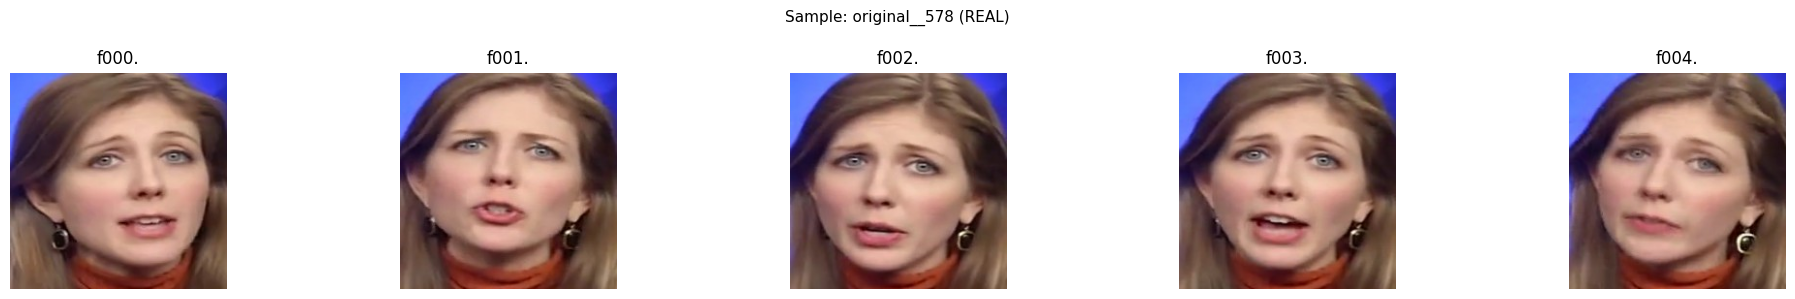

In [38]:
import matplotlib.pyplot as plt

sample_dir = f'content/faces/train/real'
sample_vid = os.listdir(sample_dir)[0]
sample_path = f'{sample_dir}/{sample_vid}'
frames = sorted(os.listdir(sample_path))

fig, axes = plt.subplots(1, len(frames), figsize=(20, 3))
for ax, fname in zip(axes, frames):
    img = Image.open(f'{sample_path}/{fname}')
    ax.imshow(img)
    ax.set_title(fname[:5])
    ax.axis('off')
plt.suptitle(f'Sample: {sample_vid} (REAL)', fontsize=11)
plt.tight_layout()
plt.show()